# 01 · Contacts, non-redundancy & TCRen derivation

Reproduces `code_paper/1_Nonred_PDB_struct.Rmd` + `2_TCRen_derivation.Rmd` with the tcren pipeline
instead of `mir.jar`. Annotates the **HF `Native2022`** structures, builds the TCR-peptide contact
table, clusters for non-redundancy, and derives the TCRen potential (+ leave-one-out).

**Regression:** the contact **geometry** computed by tcren reproduces the legacy mir contacts
exactly on every shared structure. The few chain-/region-**label** differences are where tcren is
*more* correct than mir — the γδ/βδ TCRs (TCR3D confirms `5xot`/`6bj3`/`6bj8` are Beta+Delta, which
mir mislabels as α) and cosmetic CDR-boundary placement — not geometry errors.

In [ ]:
import warnings; warnings.filterwarnings('ignore')
from pathlib import Path
import numpy as np, polars as pl
from tcren.paper import annotate_structure_set
from tcren.paper.helpers import _read_any

Path('results_new').mkdir(exist_ok=True)
NATIVE = '../data/structures/Native2022'  # shared data dir (notebooks/data)
print('Native2022 structures:', len(list(Path(NATIVE).glob('*.pdb'))))

In [2]:
# Annotate all Native2022 structures with tcren (replaces mir annotate-structures + contacts).
# Cached to results_new so downstream notebooks reuse it.
contacts_path = Path('results_new/contacts_native.csv')
markup_path = Path('results_new/markup_native.csv')
if contacts_path.exists() and markup_path.exists():
    contacts = pl.read_csv(contacts_path); markup = pl.read_csv(markup_path)
else:
    contacts, markup = annotate_structure_set(NATIVE)
    contacts.write_csv(contacts_path); markup.write_csv(markup_path)
print('contacts:', contacts.height, 'rows over', contacts['pdb.id'].n_unique(), 'structures')
markup.head()

contacts: 3647 rows over 163 structures


pdb.id,cdr3a,cdr3b,peptide,species
str,str,str,str,str
"""1ao7""","""AVTTDSWGKLQ""","""ASRPGLAGGRPEQY""","""LLFGYPVYV""","""Human"""
"""1bd2""","""AAMEGAQKLV""","""ASSYPGGGFYEQY""","""LLFGYPVYV""","""Human"""
"""1fo0""","""AMRGDYGGSGNKLI""","""TCSADRVGNTLY""","""INFDFNTI""","""Mouse"""
"""1g6r""","""AVSGFASALT""","""ASGGGGTLY""","""SIYRYYGL""","""Mouse"""
"""1jtr""","""AVSGFASALT""","""ASGGGGTLY""","""EQYKFYSV""","""Mouse"""


In [ ]:
# REGRESSION: tcren contacts vs legacy mir contacts on the shared structures.
# The hard invariant is the contact GEOMETRY (which TCR/peptide residues touch). Chain- and
# region-LABELS may differ where tcren/arda is more correct than the legacy mir; every such
# difference is adjudicated against the TCR3D oracle (data/native/tcr_chain_data.tsv).
mir = _read_any('data_legacy/contact_maps_PDB.csv.gz')
GEOM = ['residue.index.from', 'residue.index.to', 'residue.aa.from', 'residue.aa.to']
FULL = ['chain.type.from', 'region.type.from'] + GEOM
shared = sorted(set(contacts['pdb.id'].to_list()) & set(mir['pdb.id'].to_list()))

def rowset(df, pid, keys):
    return set(map(tuple, df.filter(pl.col('pdb.id') == pid).select(keys).unique().rows()))

geom_ok = full_ok = 0
chain_diffs, region_diffs = [], []
for pid in shared:
    if rowset(contacts, pid, GEOM) == rowset(mir, pid, GEOM):
        geom_ok += 1
    if rowset(contacts, pid, FULL) == rowset(mir, pid, FULL):
        full_ok += 1
    elif rowset(contacts, pid, GEOM + ['chain.type.from']) != rowset(mir, pid, GEOM + ['chain.type.from']):
        chain_diffs.append(pid)   # chain-type label differs
    else:
        region_diffs.append(pid)  # only the CDR region boundary differs

print(f'shared structures:              {len(shared)}')
print(f'GEOMETRY exact (contact pairs):  {geom_ok}/{len(shared)}')
print(f'FULL exact (+chain/region tags): {full_ok}/{len(shared)}')
print(f'\nchain-type diffs ({len(chain_diffs)}): {chain_diffs}')
print('  -> γδ/βδ TCRs. TCR3D adjudicates tcren correct (5xot/6bj3/6bj8 = Beta+Delta);')
print('     legacy mir mislabels the δ chain as α. Contact geometry is identical.')
print(f'\nregion-boundary diffs ({len(region_diffs)}): {region_diffs}')
print("  -> each is a single CDR1-anchor Tyr that TCR3D's CDR1 span includes: tcren labels it")
print('     CDR1 (= TCR3D), legacy mir mislabels it FR2. tcren follows the TCR3D authority.')

# tcren must reproduce every mir contact geometry; chain/region labels are TCR3D-adjudicated above.
assert geom_ok == len(shared), 'tcren must reproduce every legacy mir contact geometry'

In [4]:
# Non-redundancy: cluster by summed Damerau-Levenshtein distance of cdr3a+cdr3b+peptide, cut at h=6
from rapidfuzz.distance import DamerauLevenshtein
from scipy.cluster.hierarchy import linkage, fcluster
from scipy.spatial.distance import squareform

mk = markup.with_columns([pl.col(c).fill_null('') for c in ['cdr3a','cdr3b','peptide']])
ids = mk['pdb.id'].to_list()
seqs = {c: mk[c].to_list() for c in ['cdr3a','cdr3b','peptide']}
n = len(ids); D = np.zeros((n, n))
for i in range(n):
    for j in range(i+1, n):
        d = sum(DamerauLevenshtein.distance(seqs[c][i], seqs[c][j]) for c in seqs)
        D[i, j] = D[j, i] = d
Z = linkage(squareform(D), method='complete')
clusters = fcluster(Z, t=6, criterion='distance')
# one representative per cluster
seen = set(); nonred = [ids[i] for i in range(n) if not (clusters[i] in seen or seen.add(clusters[i]))]
print(f'{n} structures -> {len(set(clusters))} clusters (h=6) -> {len(nonred)} non-redundant')

163 structures -> 82 clusters (h=6) -> 82 non-redundant


In [5]:
# Derive TCRen + leave-one-out from the non-redundant HF contacts (reproduces 2_TCRen_derivation)
from tcren.potential import derive_tcren, derive_tcren_loo, tcren as published_tcren

tcren_hf = derive_tcren(contacts, include=nonred)
tcren_loo = derive_tcren_loo(contacts, nonred)
tcren_hf.to_csv('results_new/TCRen_native.csv')
tcren_loo.write_csv('results_new/TCRen_native_LOO.csv')

# Correlation with the published (latest) matrix — not identical, since HF Native2022 is a
# 163-structure subset of the paper's 196 non-redundant set, but should correlate strongly.
cmp = tcren_hf.matrix.join(published_tcren().matrix, on=['residue.aa.from','residue.aa.to'], suffix='_pub')
r = np.corrcoef(cmp['value'].to_numpy(), cmp['value_pub'].to_numpy())[0,1]
print(f'derived (HF subset) vs published TCRen: Pearson r = {r:.3f} over {cmp.height} pairs')

derived (HF subset) vs published TCRen: Pearson r = 0.675 over 380 pairs


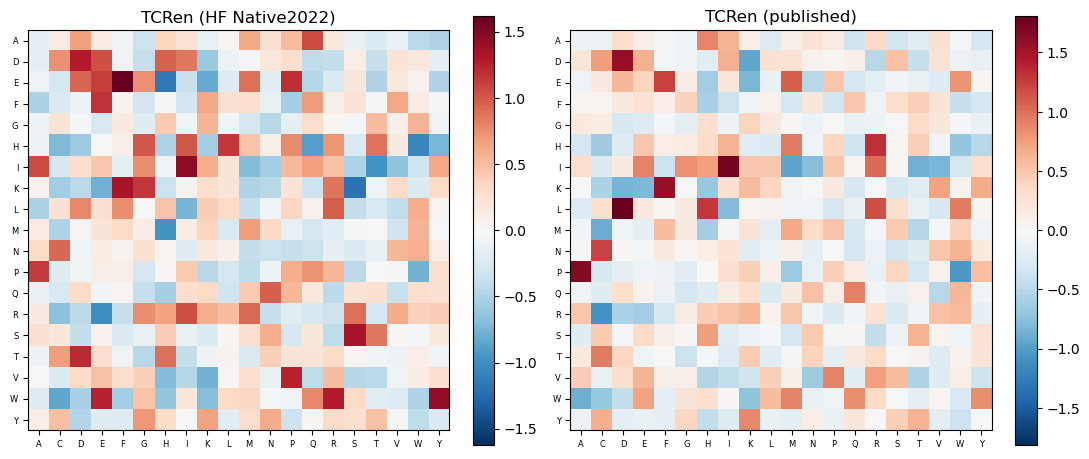

In [6]:
# Heatmaps: derived (HF) vs published TCRen
%matplotlib inline
import matplotlib.pyplot as plt
from tcren.analysis import potential_matrix
fig, axes = plt.subplots(1, 2, figsize=(11, 5))
for ax, pot, title in zip(axes, [tcren_hf, published_tcren()], ['TCRen (HF Native2022)', 'TCRen (published)']):
    m, fr, to = potential_matrix(pot); vlim = np.nanmax(np.abs(m))
    im = ax.imshow(m, cmap='RdBu_r', vmin=-vlim, vmax=vlim)
    ax.set_xticks(range(len(to))); ax.set_xticklabels(to, fontsize=6)
    ax.set_yticks(range(len(fr))); ax.set_yticklabels(fr, fontsize=6)
    ax.set_title(title); fig.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout()